# Week 2 Assignment : ML Pipeline 

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels xgboost --quiet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')


print("imports done")

imports done


### loading dataset

In [8]:
df = pd.read_csv('dataset.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Info : {df.info}')
df.head(10)

Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']
Info : <bound method DataFrame.info of       Year  Month         Region       Model  Estimated_Deliveries  \
0     2023      5         Europe     Model S                 17646   
1     2015      2           Asia     Model X                  3797   
2     2019      1  North America     Model X                  8411   
3     2021      2  North America     Model 3                  6555   
4     2016     12    Middle East     Model Y                 12374   
...    ...    ...            ...         ...                   ...   
2635  2021     10    Middle East     Model Y                 13488   
2636  2019      7    Middle East     Model S                 18300   
2637  2019      9           Asia     Model S                 13291   
2638  2020      5           Asia  Cybertruck  

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


### Preprocessing

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0] if missing.any() else 'No missing values found')

No missing values found


In [11]:
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape after removing duplicates: {df.shape}')

Duplicate rows: 0
Shape after removing duplicates: (2640, 12)


In [17]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
df['Date'].head()

0   2023-05-01
1   2015-02-01
2   2019-01-01
3   2021-02-01
4   2016-12-01
Name: Date, dtype: datetime64[ns]

In [18]:
print('Delivery range:', df['Estimated_Deliveries'].min(), '–', df['Estimated_Deliveries'].max())
print('Price range ($):', df['Avg_Price_USD'].min(), '–', df['Avg_Price_USD'].max())
print('Production range:', df['Production_Units'].min(), '–', df['Production_Units'].max())

df = df[(df['Estimated_Deliveries'] > 0) & (df['Production_Units'] > 0)]
print(f'\nClean dataset shape: {df.shape}')

Delivery range: 48 – 25704
Price range ($): 50003.7 – 119965.36
Production range: 50 – 28939

Clean dataset shape: (2640, 13)


In [19]:

cat_cols = ['Region', 'Model', 'Source_Type']
le = LabelEncoder()
df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col + '_enc'] = le.fit_transform(df_encoded[col])

print('Unique values per category:')
for col in cat_cols:
    print(f'  {col}: {df[col].unique()}')

Unique values per category:
  Region: ['Europe' 'Asia' 'North America' 'Middle East']
  Model: ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
  Source_Type: ['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


In [20]:
def detect_outliers_iqr(series, label):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)).sum()
    print(f'{label}: {outliers} outliers ({outliers/len(series)*100:.1f}%)')

for col in ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'CO2_Saved_tons']:
    detect_outliers_iqr(df[col], col)

Estimated_Deliveries: 12 outliers (0.5%)
Production_Units: 12 outliers (0.5%)
Avg_Price_USD: 0 outliers (0.0%)
CO2_Saved_tons: 45 outliers (1.7%)


### EDA

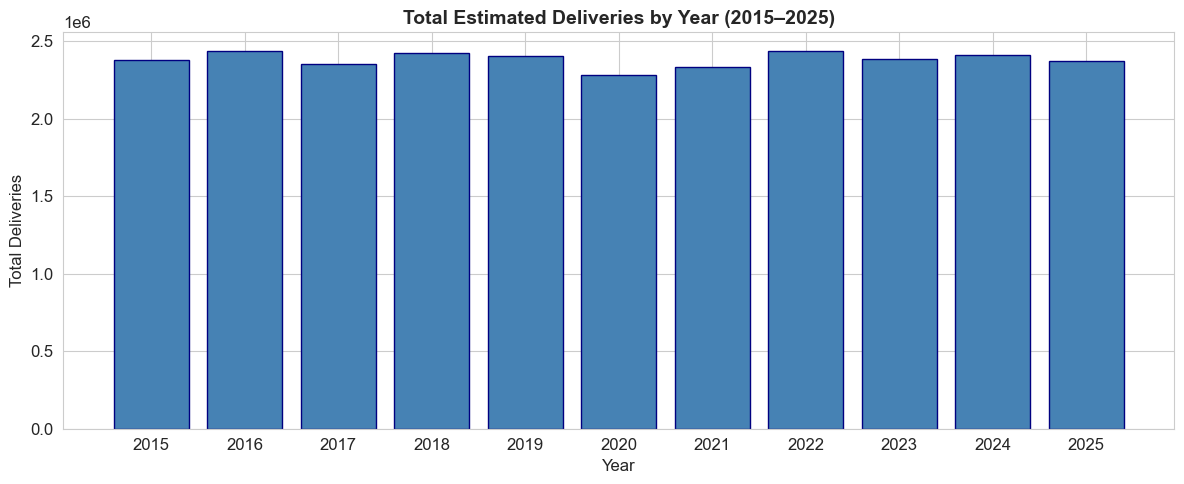

In [21]:
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.bar(yearly['Year'], yearly['Estimated_Deliveries'], color='steelblue', edgecolor='navy')
plt.title('Total Estimated Deliveries by Year (2015–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.xticks(yearly['Year'])
plt.tight_layout()
plt.show()

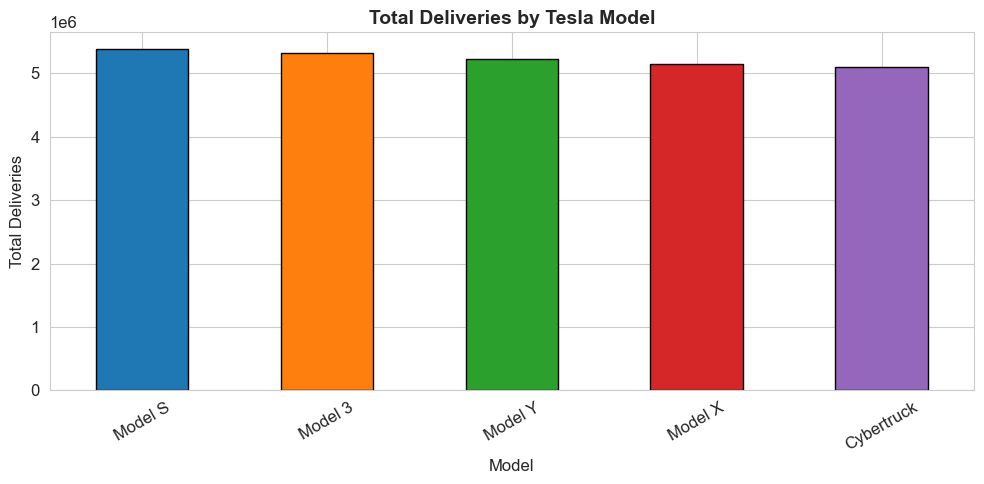

In [22]:
model_del = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
model_del.plot(kind='bar', color=sns.color_palette('tab10'), edgecolor='black')
plt.title('Total Deliveries by Tesla Model', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Total Deliveries')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

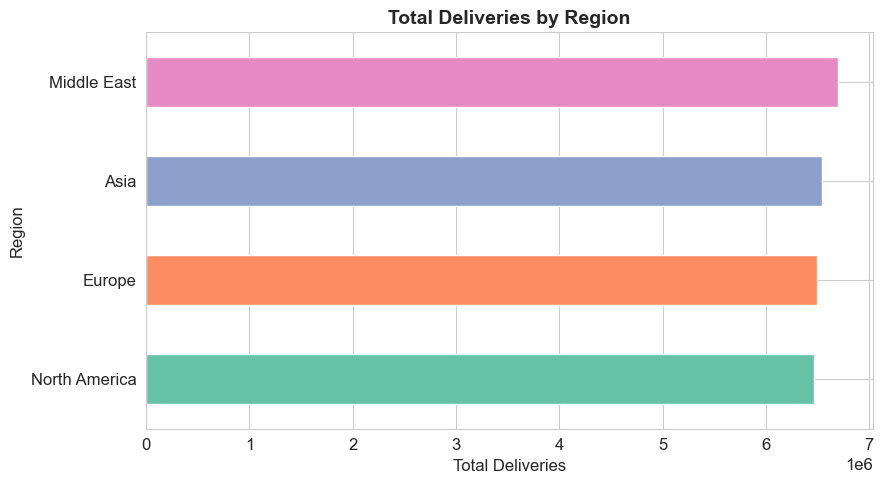

In [23]:
region_del = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values()

plt.figure(figsize=(9, 5))
region_del.plot(kind='barh', color=sns.color_palette('Set2'))
plt.title('Total Deliveries by Region', fontsize=14, fontweight='bold')
plt.xlabel('Total Deliveries')
plt.tight_layout()
plt.show()

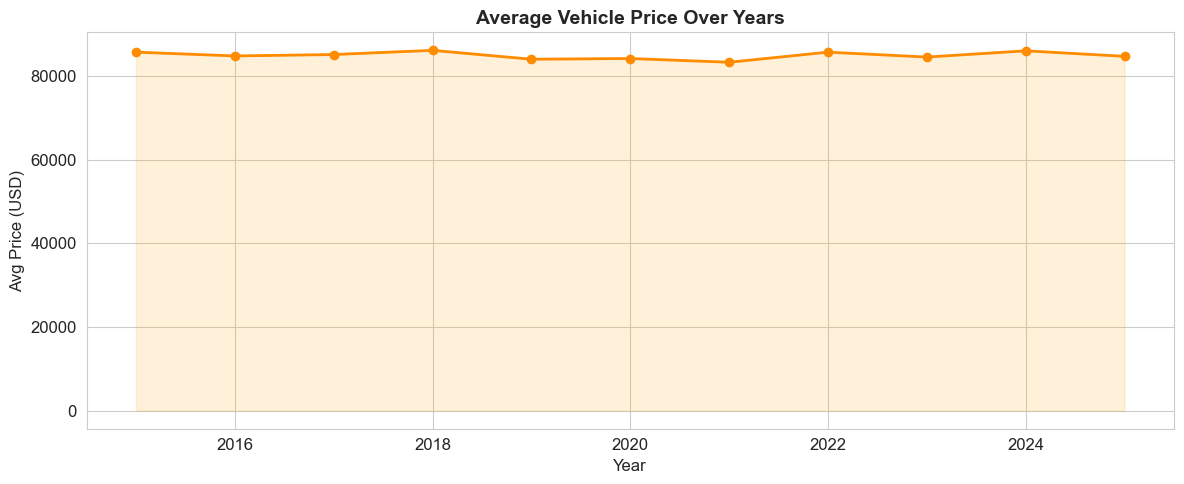

In [24]:
price_trend = df.groupby('Year')['Avg_Price_USD'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(price_trend['Year'], price_trend['Avg_Price_USD'], marker='o', color='darkorange', linewidth=2)
plt.fill_between(price_trend['Year'], price_trend['Avg_Price_USD'], alpha=0.15, color='orange')
plt.title('Average Vehicle Price Over Years', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Avg Price (USD)')
plt.tight_layout()
plt.show()

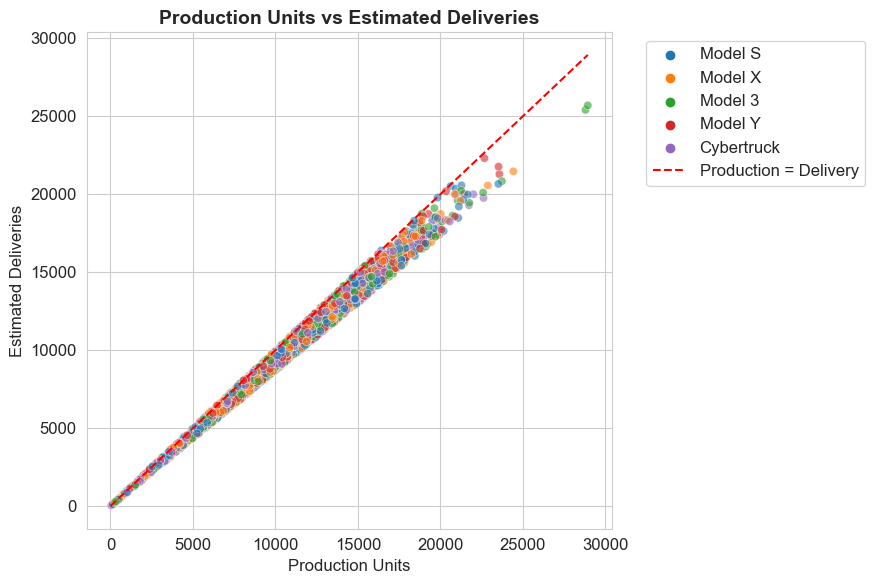

In [25]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Production_Units', y='Estimated_Deliveries', hue='Model', alpha=0.6)
# Perfect delivery line
max_val = max(df['Production_Units'].max(), df['Estimated_Deliveries'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Production = Delivery')
plt.title('Production Units vs Estimated Deliveries', fontsize=14, fontweight='bold')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

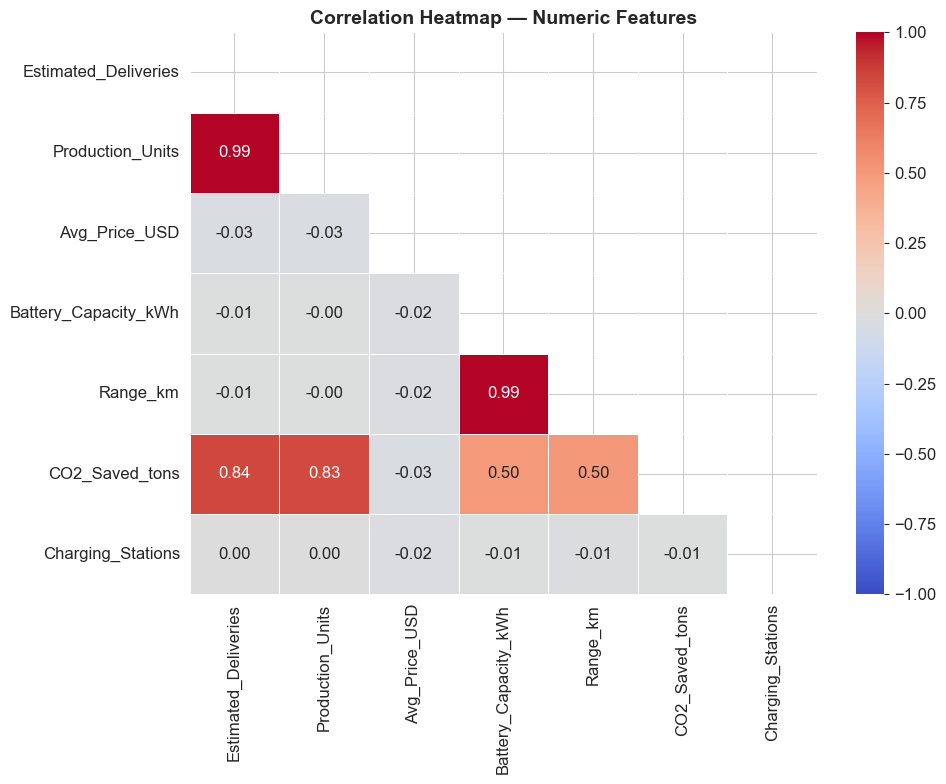

In [26]:
num_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

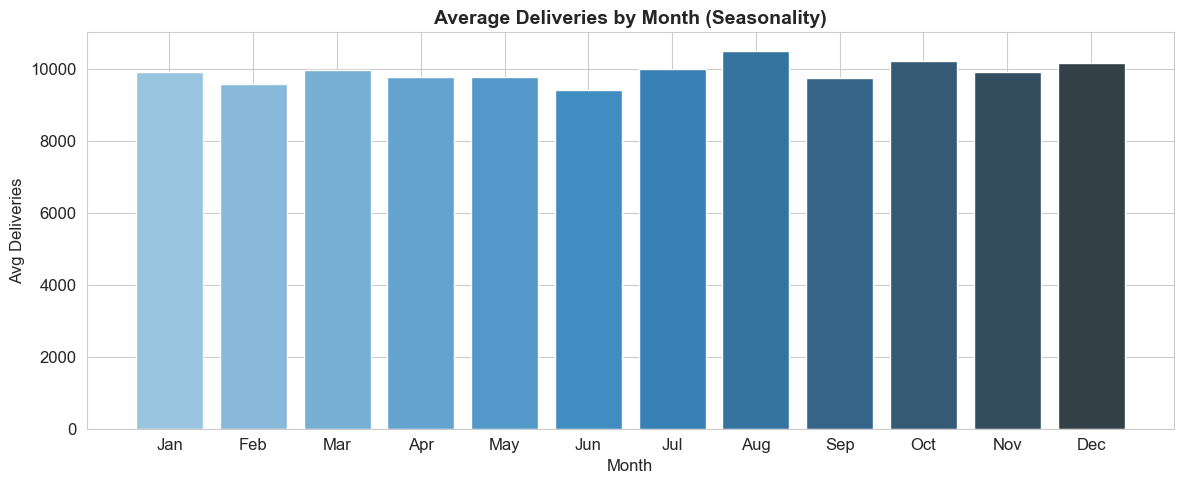

In [27]:
monthly = df.groupby('Month')['Estimated_Deliveries'].mean()

plt.figure(figsize=(12, 5))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.bar(month_names, monthly.values, color=sns.color_palette('Blues_d', 12))
plt.title('Average Deliveries by Month (Seasonality)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Avg Deliveries')
plt.tight_layout()
plt.show()

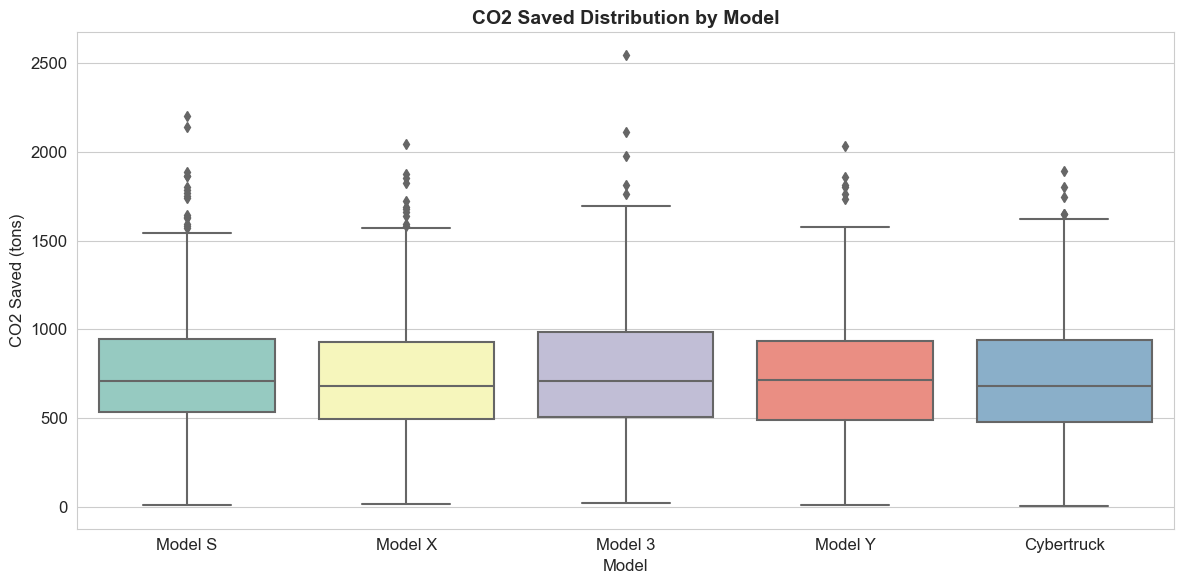

In [28]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Model', y='CO2_Saved_tons', palette='Set3')
plt.title('CO2 Saved Distribution by Model', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('CO2 Saved (tons)')
plt.tight_layout()
plt.show()

### Feature Engineering

In [29]:
df_feat = df_encoded.copy()

df_feat['Quarter'] = df_feat['Date'].dt.quarter
df_feat['Is_Q4']   = (df_feat['Quarter'] == 4).astype(int)  # Tesla's strongest quarter
df_feat['Year_Norm'] = df_feat['Year'] - df_feat['Year'].min()  # Years since 2015

print('Added: Quarter, Is_Q4, Year_Norm')

Added: Quarter, Is_Q4, Year_Norm


In [30]:
df_feat['Production_Surplus'] = df_feat['Production_Units'] - df_feat['Estimated_Deliveries']
df_feat['Delivery_Rate']      = df_feat['Estimated_Deliveries'] / df_feat['Production_Units']
df_feat['CO2_per_Delivery']   = df_feat['CO2_Saved_tons'] / df_feat['Estimated_Deliveries']
df_feat['Price_per_Range']    = df_feat['Avg_Price_USD'] / df_feat['Range_km']

print('Added: Production_Surplus, Delivery_Rate, CO2_per_Delivery, Price_per_Range')

Added: Production_Surplus, Delivery_Rate, CO2_per_Delivery, Price_per_Range


In [31]:
df_feat_sorted = df_feat.sort_values('Date').reset_index(drop=True)

df_feat_sorted['Rolling_Delivery_3'] = (
    df_feat_sorted.groupby(['Region', 'Model'])['Estimated_Deliveries']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

df_feat_sorted['Rolling_Price_3'] = (
    df_feat_sorted.groupby(['Region', 'Model'])['Avg_Price_USD']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

print('Added: Rolling_Delivery_3, Rolling_Price_3')

Added: Rolling_Delivery_3, Rolling_Price_3


In [33]:
df_feat_sorted['Lag1_Deliveries'] = (
    df_feat_sorted.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1)
)
df_feat_sorted['Lag2_Deliveries'] = (
    df_feat_sorted.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(2)
)

df_feat_sorted['Lag1_Deliveries'].fillna(df_feat_sorted['Estimated_Deliveries'].median(), inplace=True)
df_feat_sorted['Lag2_Deliveries'].fillna(df_feat_sorted['Estimated_Deliveries'].median(), inplace=True)

print('Added: Lag1_Deliveries, Lag2_Deliveries')
df_feat_sorted[['Year','Month','Model','Estimated_Deliveries',
                'Lag1_Deliveries','Lag2_Deliveries','Rolling_Delivery_3']].head(10)

Added: Lag1_Deliveries, Lag2_Deliveries


,Year,Month,Model,Estimated_Deliveries,Lag1_Deliveries,Lag2_Deliveries,Rolling_Delivery_3
0,2015,1,Model Y,12446,9857.0,9857.0,12446.0
1,2015,1,Model 3,11446,9857.0,9857.0,11446.0
2,2015,1,Cybertruck,8803,9857.0,9857.0,8803.0
3,2015,1,Cybertruck,6367,9857.0,9857.0,6367.0
4,2015,1,Model 3,8795,9857.0,9857.0,8795.0
5,2015,1,Cybertruck,2161,9857.0,9857.0,2161.0
6,2015,1,Model S,11986,9857.0,9857.0,11986.0
7,2015,1,Model X,8833,9857.0,9857.0,8833.0
8,2015,1,Model 3,9446,9857.0,9857.0,9446.0
9,2015,1,Model S,4350,9857.0,9857.0,4350.0


In [34]:
feature_cols = [
    'Year_Norm', 'Month', 'Quarter', 'Is_Q4',
    'Region_enc', 'Model_enc', 'Source_Type_enc',
    'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
    'Range_km', 'CO2_Saved_tons', 'Charging_Stations',
    'Production_Surplus', 'Delivery_Rate', 'CO2_per_Delivery',
    'Price_per_Range', 'Rolling_Delivery_3', 'Rolling_Price_3',
    'Lag1_Deliveries', 'Lag2_Deliveries'
]
target_col = 'Estimated_Deliveries'

print(f'Total features: {len(feature_cols)}')
print('Features:', feature_cols)

Total features: 21
Features: ['Year_Norm', 'Month', 'Quarter', 'Is_Q4', 'Region_enc', 'Model_enc', 'Source_Type_enc', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Production_Surplus', 'Delivery_Rate', 'CO2_per_Delivery', 'Price_per_Range', 'Rolling_Delivery_3', 'Rolling_Price_3', 'Lag1_Deliveries', 'Lag2_Deliveries']


### Regression Modeling

In [35]:
from sklearn.impute import SimpleImputer

X = df_feat_sorted[feature_cols].copy()
y = df_feat_sorted[target_col]

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')
print(f'NaN in X after imputing: {pd.DataFrame(X_train_sc).isnull().sum().sum()}')

Train size: (2112, 21), Test size: (528, 21)
NaN in X after imputing: 0


In [36]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, scaled=False):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    mae   = mean_absolute_error(y_te, preds)
    r2    = r2_score(y_te, preds)
    cv    = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    print(f'{name:<30} RMSE={rmse:>8.1f}  MAE={mae:>8.1f}  R²={r2:.4f}  CV-R²={cv:.4f}')
    return {'Model': name, 'RMSE': round(rmse, 2), 'MAE': round(mae, 2),
            'R2': round(r2, 4), 'CV_R2': round(cv, 4), 'predictions': preds}

results = []

In [37]:
print(f'{"Model":<30} {"RMSE":>10}  {"MAE":>10}  {"R²":>8}  {"CV-R²":>8}')
print('-' * 72)

# Linear models 
results.append(evaluate_model('Linear Regression',    LinearRegression(),  X_train_sc, y_train, X_test_sc, y_test))
results.append(evaluate_model('Ridge Regression',     Ridge(alpha=1.0),    X_train_sc, y_train, X_test_sc, y_test))
results.append(evaluate_model('Lasso Regression',     Lasso(alpha=0.1),    X_train_sc, y_train, X_test_sc, y_test))

# Tree-based models
results.append(evaluate_model('Random Forest',        RandomForestRegressor(n_estimators=100, random_state=42),   X_train, y_train, X_test, y_test))
results.append(evaluate_model('Gradient Boosting',    GradientBoostingRegressor(n_estimators=100, random_state=42), X_train, y_train, X_test, y_test))
results.append(evaluate_model('XGBoost',              XGBRegressor(n_estimators=100, random_state=42, verbosity=0), X_train, y_train, X_test, y_test))

Model                                RMSE         MAE        R²     CV-R²
------------------------------------------------------------------------
Linear Regression              RMSE=     0.0  MAE=     0.0  R²=1.0000  CV-R²=1.0000
Ridge Regression               RMSE=    10.3  MAE=     7.1  R²=1.0000  CV-R²=1.0000
Lasso Regression               RMSE=     1.3  MAE=     0.6  R²=1.0000  CV-R²=1.0000
Random Forest                  RMSE=   122.4  MAE=    65.3  R²=0.9990  CV-R²=0.9982
Gradient Boosting              RMSE=    87.9  MAE=    64.7  R²=0.9995  CV-R²=0.9991
XGBoost                        RMSE=    98.8  MAE=    70.0  R²=0.9993  CV-R²=0.9968


In [39]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'predictions'} for r in results])
results_df.sort_values('R2', ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)
print('\nModel Comparison:')
results_df


Model Comparison:


,Model,RMSE,MAE,R2,CV_R2
0,Linear Regression,0.00,0.00,1.0000,1.0000
1,Ridge Regression,10.30,7.06,1.0000,1.0000
2,Lasso Regression,1.26,0.64,1.0000,1.0000
3,Gradient Boosting,87.88,64.74,0.9995,0.9991
4,XGBoost,98.76,70.04,0.9993,0.9968
5,Random Forest,122.41,65.33,0.9990,0.9982


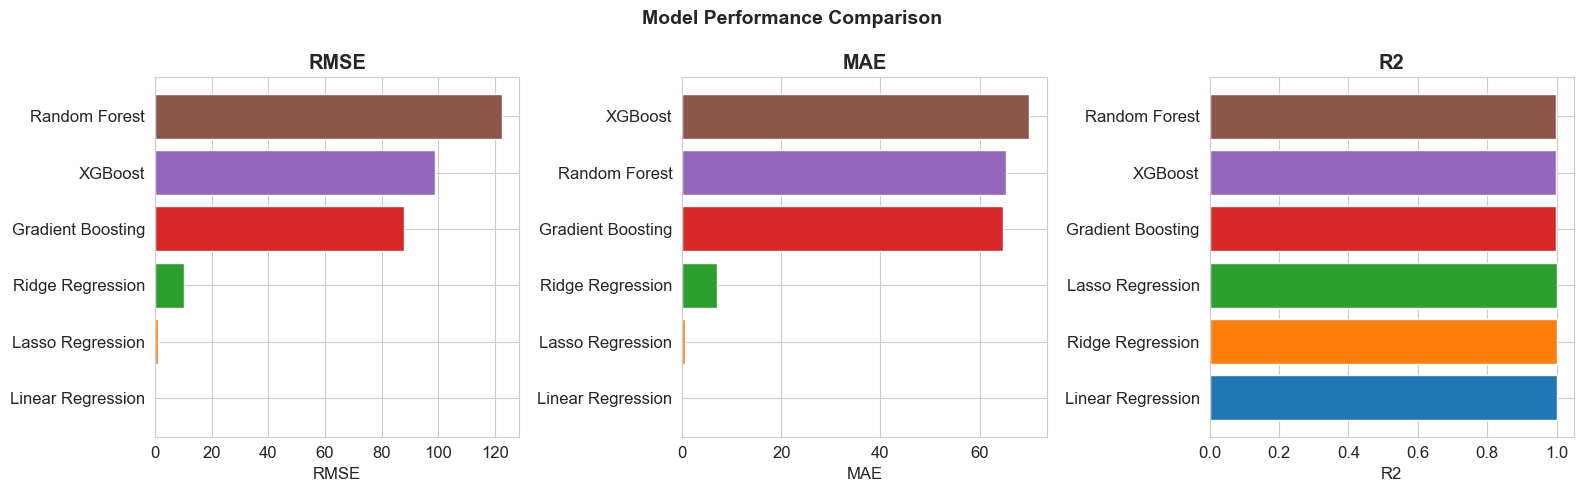

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['RMSE', 'MAE', 'R2']
colors = sns.color_palette('tab10', len(results_df))

for ax, metric in zip(axes, metrics):
    ascending = True if metric in ['RMSE', 'MAE'] else False
    data = results_df.sort_values(metric, ascending=ascending)
    ax.barh(data['Model'], data[metric], color=colors)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel(metric)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

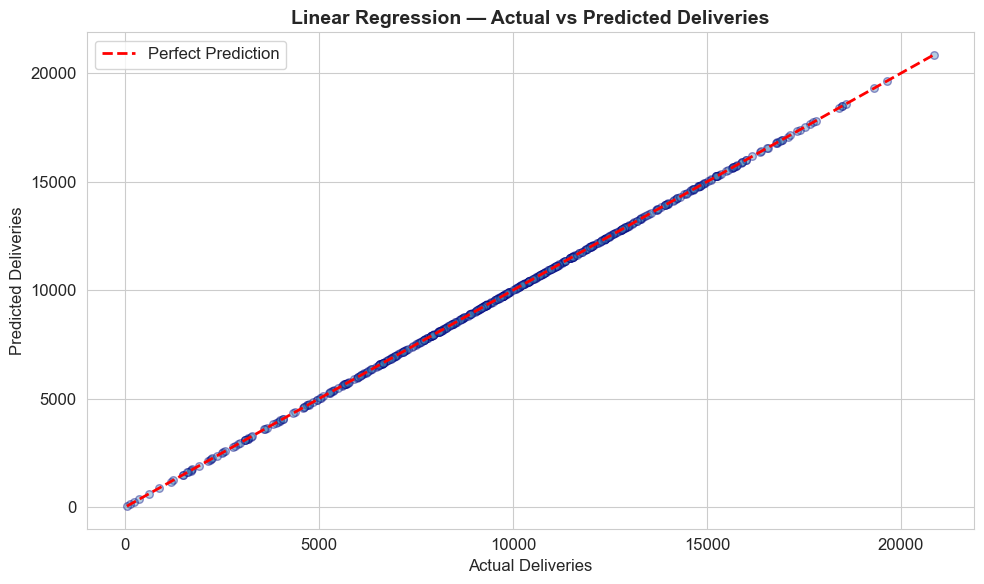

In [41]:
best_model_name = results_df.iloc[0]['Model']
best_result = next(r for r in results if r['Model'] == best_model_name)
preds_best = best_result['predictions']

plt.figure(figsize=(10, 6))
plt.scatter(y_test, preds_best, alpha=0.4, color='steelblue', edgecolors='navy', s=30)
lims = [min(y_test.min(), preds_best.min()), max(y_test.max(), preds_best.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
plt.title(f'{best_model_name} — Actual vs Predicted Deliveries', fontsize=14, fontweight='bold')
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

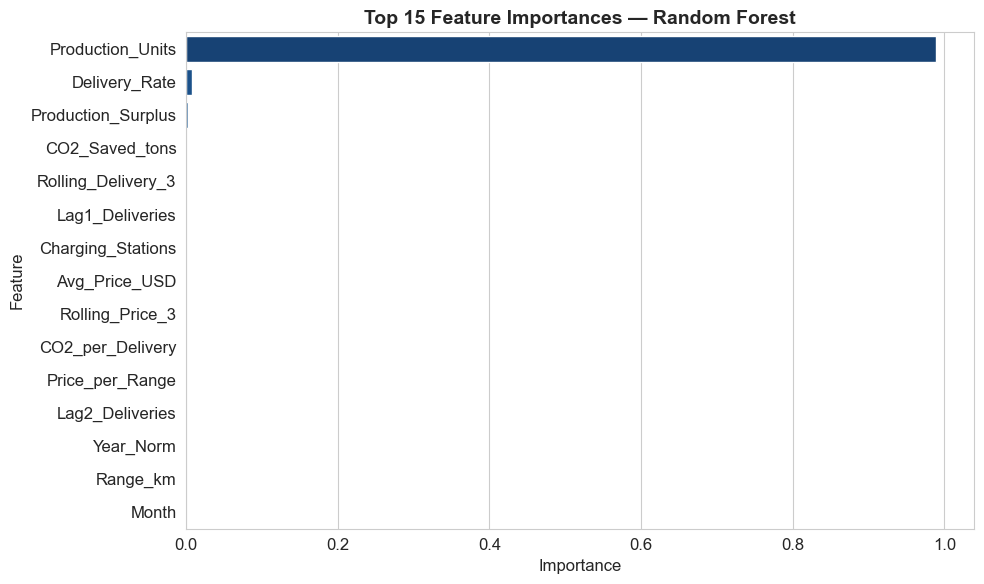

In [42]:
best_tree = RandomForestRegressor(n_estimators=100, random_state=42)
best_tree.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_tree.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 15 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning

In [44]:
print('Running GridSearchCV on Random Forest ')

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train, y_train)

print(f'\nBest RF Parameters: {rf_grid.best_params_}')
print(f'   Best CV R²: {rf_grid.best_score_:.4f}')

Running GridSearchCV on Random Forest 

Best RF Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
   Best CV R²: 0.9791


In [45]:
print('Running GridSearchCV on XGBoost...')

xgb_params = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [3, 5, 7],
    'subsample':     [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
xgb_grid.fit(X_train, y_train)

print(f'\nBest XGB Parameters: {xgb_grid.best_params_}')
print(f'Best CV R²: {xgb_grid.best_score_:.4f}')

Running GridSearchCV on XGBoost...

Best XGB Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV R²: 0.9977


In [46]:
models_compare = {
    'RF (Default)': RandomForestRegressor(n_estimators=100, random_state=42),
    'RF (Tuned)':   rf_grid.best_estimator_,
    'XGB (Default)': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'XGB (Tuned)':   xgb_grid.best_estimator_,
}

print(f'{"Model":<20} {"RMSE":>10}  {"R²":>8}')
print('-' * 42)
tuning_results = []
for name, model in models_compare.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    print(f'{name:<20} {rmse:>10.1f}  {r2:>8.4f}')
    tuning_results.append({'Model': name, 'RMSE': rmse, 'R2': r2})

Model                      RMSE        R²
------------------------------------------
RF (Default)              122.4    0.9990
RF (Tuned)                399.0    0.9894
XGB (Default)              98.8    0.9993
XGB (Tuned)                88.9    0.9995


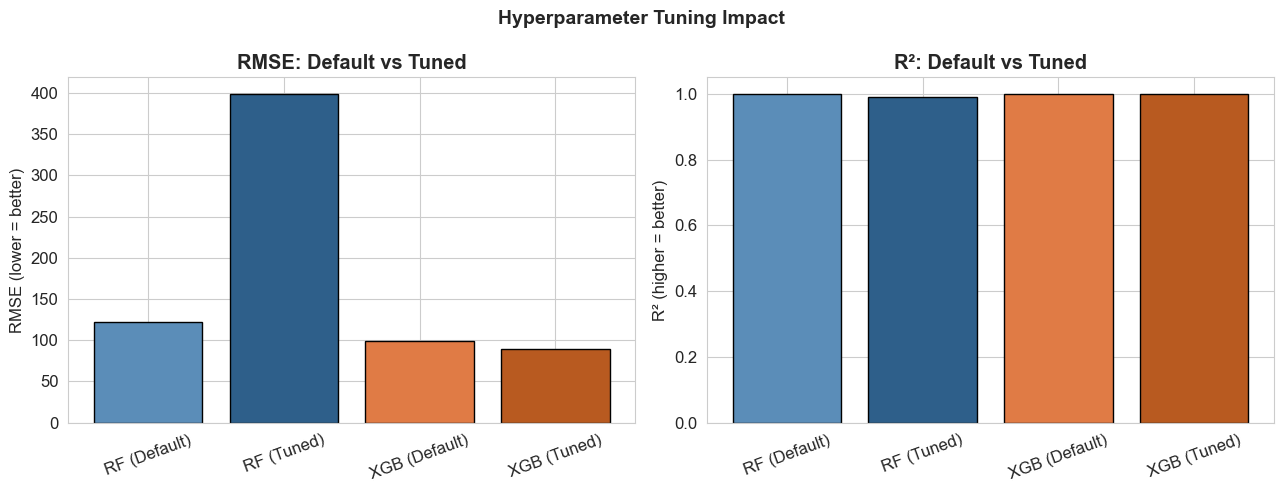

In [47]:
tuning_df = pd.DataFrame(tuning_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
clrs = ['#5B8DB8', '#2E5F8A', '#E07B45', '#B85A20']

axes[0].bar(tuning_df['Model'], tuning_df['RMSE'], color=clrs, edgecolor='black')
axes[0].set_title('RMSE: Default vs Tuned', fontweight='bold')
axes[0].set_ylabel('RMSE (lower = better)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(tuning_df['Model'], tuning_df['R2'], color=clrs, edgecolor='black')
axes[1].set_title('R²: Default vs Tuned', fontweight='bold')
axes[1].set_ylabel('R² (higher = better)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(0, 1.05)

plt.suptitle('Hyperparameter Tuning Impact', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Time Series Forecasting

Time series length: 132 months
Range: 2015-01-01 00:00:00 → 2025-12-01 00:00:00


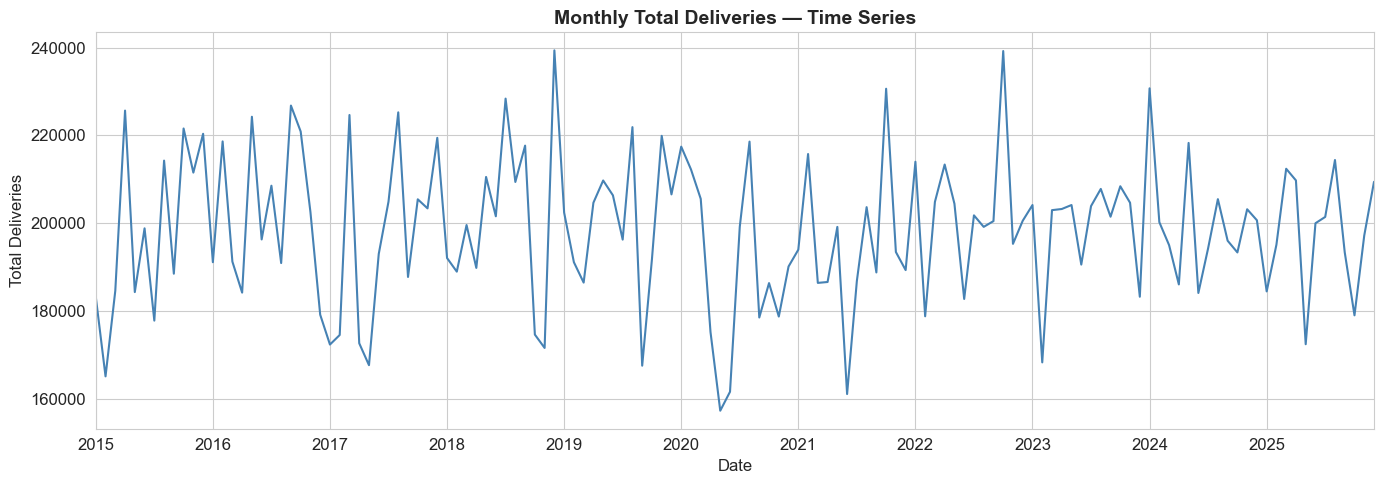

In [48]:
ts_df = df.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().reset_index()
ts_df['Date'] = pd.to_datetime(ts_df[['Year', 'Month']].assign(Day=1))
ts_df = ts_df.set_index('Date').sort_index()['Estimated_Deliveries']
ts_df = ts_df.asfreq('MS')  # Monthly start frequency

print(f'Time series length: {len(ts_df)} months')
print(f'Range: {ts_df.index.min()} → {ts_df.index.max()}')

plt.figure(figsize=(14, 5))
ts_df.plot(color='steelblue', linewidth=1.5)
plt.title('Monthly Total Deliveries — Time Series', fontsize=14, fontweight='bold')
plt.ylabel('Total Deliveries')
plt.tight_layout()
plt.show()

In [49]:
adf_result = adfuller(ts_df.dropna())
print('ADF Stationarity Test:')
print(f'  ADF Statistic : {adf_result[0]:.4f}')
print(f'  p-value       : {adf_result[1]:.4f}')
print(f'  Stationary    : {"Yes" if adf_result[1] < 0.05 else "No (differencing needed)"}')

ADF Stationarity Test:
  ADF Statistic : -8.8810
  p-value       : 0.0000
  Stationary    : Yes


In [50]:
n_forecast = 12  # Predict next 12 months
ts_train   = ts_df[:-n_forecast]
ts_test    = ts_df[-n_forecast:]

print(f'Training: {ts_train.index.min()} → {ts_train.index.max()} ({len(ts_train)} months)')
print(f'Testing : {ts_test.index.min()} → {ts_test.index.max()} ({len(ts_test)} months)')

Training: 2015-01-01 00:00:00 → 2024-12-01 00:00:00 (120 months)
Testing : 2025-01-01 00:00:00 → 2025-12-01 00:00:00 (12 months)


In [51]:
hw_model  = ExponentialSmoothing(ts_train, trend='add', seasonal='add', seasonal_periods=12)
hw_fit    = hw_model.fit(optimized=True)
hw_fc     = hw_fit.forecast(n_forecast)

hw_rmse   = np.sqrt(mean_squared_error(ts_test, hw_fc))
hw_mae    = mean_absolute_error(ts_test, hw_fc)
hw_r2     = r2_score(ts_test, hw_fc)
print(f'Holt-Winters  →  RMSE={hw_rmse:.0f}  MAE={hw_mae:.0f}  R²={hw_r2:.4f}')

Holt-Winters  →  RMSE=14189  MAE=10490  R²=-0.2164


In [52]:
arima_model = ARIMA(ts_train, order=(2, 1, 2))
arima_fit   = arima_model.fit()
arima_fc    = arima_fit.forecast(steps=n_forecast)

arima_rmse  = np.sqrt(mean_squared_error(ts_test, arima_fc))
arima_mae   = mean_absolute_error(ts_test, arima_fc)
arima_r2    = r2_score(ts_test, arima_fc)
print(f'ARIMA(2,1,2)  →  RMSE={arima_rmse:.0f}  MAE={arima_mae:.0f}  R²={arima_r2:.4f}')

ARIMA(2,1,2)  →  RMSE=13085  MAE=10536  R²=-0.0346


In [ ]:
# ── 7.6 Forecast Comparison Plot ──
plt.figure(figsize=(15, 6))
plt.plot(ts_train.index, ts_train, color='steelblue', linewidth=1.5, label='Training Data')
plt.plot(ts_test.index,  ts_test,  color='black',     linewidth=2,   label='Actual (Test)', linestyle='--')
plt.plot(ts_test.index,  hw_fc,    color='darkorange', linewidth=2,  label=f'Holt-Winters (R²={hw_r2:.3f})')
plt.plot(ts_test.index,  arima_fc, color='green',     linewidth=2,   label=f'ARIMA (R²={arima_r2:.3f})')

plt.axvline(ts_test.index[0], color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
plt.title('Time Series Forecast: Holt-Winters vs ARIMA', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
hw_full   = ExponentialSmoothing(ts_df, trend='add', seasonal='add', seasonal_periods=12)
hw_full_fit = hw_full.fit(optimized=True)
future_fc = hw_full_fit.forecast(12)

plt.figure(figsize=(15, 6))
plt.plot(ts_df.index, ts_df, color='steelblue', linewidth=1.5, label='Historical Data')
plt.plot(future_fc.index, future_fc, color='red', linewidth=2.5, linestyle='--', label='12-Month Future Forecast')
plt.fill_between(future_fc.index,
                 future_fc * 0.90, future_fc * 1.10,
                 alpha=0.2, color='red', label='±10% Confidence Band')
plt.axvline(ts_df.index[-1], color='gray', linestyle=':', label='Forecast Starts')
plt.title('Tesla Deliveries — 12-Month Future Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

print('\nForecasted Monthly Deliveries:')
print(future_fc.round(0).astype(int).to_string())

### Final Summary

In [ ]:
print('=' * 65)
print('        TESLA ML PIPELINE — FINAL RESULTS SUMMARY')
print('=' * 65)

print('\nDATASET')
print(f'  Rows: {df.shape[0]} | Columns: {df.shape[1]}')
print(f'  Period: {df["Year"].min()} – {df["Year"].max()}')
print(f'  Models: {sorted(df["Model"].unique())}')
print(f'  Regions: {sorted(df["Region"].unique())}')

print('\nFEATURES ENGINEERED')
print(f'  Total: {len(feature_cols)} features')
print(f'  Includes: lag, rolling, temporal, interaction features')

print('\nBEST REGRESSION MODEL')
best_row = results_df.iloc[0]
print(f'  Model : {best_row["Model"]}')
print(f'  R²    : {best_row["R2"]}')
print(f'  RMSE  : {best_row["RMSE"]}')
print(f'  MAE   : {best_row["MAE"]}')

best_ts = 'Holt-Winters' if hw_r2 >= arima_r2 else 'ARIMA'
best_ts_r2 = max(hw_r2, arima_r2)
print('\nBEST TIME SERIES MODEL')
print(f'  Model : {best_ts}')
print(f'  R²    : {best_ts_r2:.4f}')
print(f'  RMSE  : {min(hw_rmse, arima_rmse):.0f}')

print('\n' + '=' * 65)